In [7]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
# import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Coleta dos dados

In [8]:
results_flows_directories = glob.glob('../../results/results_flows*/*')
results_flows_directories

['../../results/results_flows/backup 1',
 '../../results/results_flows/backup 2',
 '../../results/results_flows/hephaestusMaskablePPO_s_50_p_6_a_1.0_c_0',
 '../../results/results_flows/ga_s_50_p_6_a_1.0_c_0',
 '../../results/results_flows/kuririnMaskablePPO_s_50_p_6_a_1.0_c_0',
 '../../results/results_flows/darsppoMaskablePPO_s_50_p_6_a_1.0_c_0']

In [9]:
metricas_de_coleta = ['tempo',
                        'cpu_utilization',
                        'gpu_utilization',
                        'cache_utilization',
                        'network_cpu_utilization', 
                        'network_gpu_utilization', 
                        'network_cache_utilization', 
                        'mobile_cpu_utilization', 
                        'mobile_gpu_utilization', 
                        'mobile_cache_utilization',
                        'bandwidth_utilization',
                        'bandwidth_utilization_per_flow',
                        'success',
                        'latency',
                        'decision_time_ms',
                        'running_sfcs',
                        'cpu_saved',
                        'shared_vnfs',
                        'shared_vnfs_per_flow',
                        'cpu_per_flow',
                        'gpu_per_flow',
                        'cache_per_flow',
                        "total_energy_consumption",
                        "jain_fairness_latencia_por_sessao",
                        "acceptance_rate",
                        "energy_consumption_per_flow",
                        "queue_time",
                        "jain_cpu",
                        "jain_gpu",
                        "jain_cache",
                        "jain_bw"
                        ]

### Função auxiliar que insere a coluna de desvio padrão da latencia nas SFCs de mesma sessão

In [10]:



import pandas as pd
import numpy as np

def jain_fairness_index(x):
    """
    Calcula o Jain's Fairness Index para uma pandas Series (x).
    Retorna 1.0 se todos os valores forem 0 (perfeitamente justo).
    Retorna np.nan se a série estiver vazia ou contiver apenas NaNs.
    """
    # Remover valores NaN para o cálculo
    x = x.dropna()
    
    # Contar o número de elementos
    n = len(x)
    
    # Se não houver elementos (grupo vazio ou só NaN),
    # retornar NaN para ser tratado pelo .fillna(0) posteriormente
    if n == 0:
        return np.nan
    
    # Calcular a soma dos quadrados
    sum_sq = (x * x).sum()
    
    # Caso especial: se a soma dos quadrados for 0, 
    # todos os valores são 0. Isso é perfeitamente justo.
    if sum_sq == 0:
        return 1.0
        
    # Calcular a soma dos valores
    sum_val = x.sum()
    
    # Fórmula de Jain
    numerator = sum_val ** 2
    denominator = n * sum_sq
    
    return numerator / denominator


def calcular_jain_fairness_por_sessao(df):
    """
    Calcula o Jain's Fairness Index da latência por sessão e 
    o adiciona ao DataFrame.

    A sessão é extraída da coluna 'sfc_id' (ex: 'sfc_unique_p5_1' -> sessão '1').
    O índice de Jain para um grupo vazio (ou com apenas NaNs) é 'NaN', que é
    convertido para 0. Um grupo com um único valor terá índice 1.0 (justiça perfeita).

    Argumentos:
        df (pd.DataFrame): O DataFrame de entrada. Deve conter as colunas
                             'sfc_id' e 'latency'.

    Retorna:
        pd.DataFrame: Uma cópia do DataFrame original com a nova coluna
                           'jain_fairness_latencia_por_sessao'.
    """
    # Criar uma cópia para evitar modificar o DataFrame original (boa prática)
    df_modificado = df.copy()

    # 1. Extrair o ID da sessão da coluna 'sfc_id'
    df_modificado['session_id'] = df_modificado['sfc_id'].str.split('_').str[-1]

    # 2. Calcular o Jain's Fairness Index da 'latency' para cada 'session_id'
    #    Esta é a linha que foi alterada:
    df_modificado['jain_fairness_latencia_por_sessao'] = df_modificado.groupby('session_id')['latency'].transform(jain_fairness_index)

    # 3. Substituir NaN por 0 (ocorre em sessões vazias ou com apenas NaNs)
    df_modificado['jain_fairness_latencia_por_sessao'] = df_modificado['jain_fairness_latencia_por_sessao'].fillna(0)

    # 4. Remover coluna temporária
    df_modificado = df_modificado.drop(columns=['session_id'])

    return df_modificado


def calcular_consumo_energia_por_fluxo(df):
    """
    Calcula o consumo de energia por fluxo e o adiciona ao DataFrame.

    A nova coluna se chamará 'energy_consumption_per_flow'.
    O cálculo é 'total_energy_consumption' / 'running_sfcs'.

    Casos onde 'running_sfcs' é 0 terão o resultado definido como 0.0.
    """
    df_modificado = df.copy()
    nova_coluna = 'energy_consumption_per_flow'

    df_modificado[nova_coluna] = np.where(
        df_modificado['running_sfcs'] == 0,
        0.0,
        df_modificado['total_energy_consumption'] / df_modificado['running_sfcs']
    )

    return df_modificado


def calcular_banda_por_fluxo(df):
    """
    Calcula a banda utilizada por fluxo e o adiciona ao DataFrame.

    A nova coluna se chamará 'bandwidth_utilization_per_flow'.
    O cálculo é 'bandwidth_utilization' / 'running_sfcs'.

    Casos onde 'running_sfcs' é 0 terão o resultado definido como 0.0.
    """
    df_modificado = df.copy()
    nova_coluna = 'bandwidth_utilization_per_flow'

    df_modificado[nova_coluna] = np.where(
        df_modificado['running_sfcs'] == 0,
        0.0,
        df_modificado['bandwidth_utilization'] / df_modificado['running_sfcs']
    )

    return df_modificado


def calcular_shared_vnfs_por_fluxo(df):
    """
    Calcula a quantidade de VNFs compartilhadas por fluxo e adiciona ao DataFrame.

    A nova coluna se chamará 'shared_vnfs_per_flow'.
    O cálculo é 'shared_vnfs' / 'running_sfcs'.

    Casos onde 'running_sfcs' é 0 terão o resultado definido como 0.0.
    """
    df_modificado = df.copy()
    nova_coluna = 'shared_vnfs_per_flow'

    df_modificado[nova_coluna] = np.where(
        df_modificado['running_sfcs'] == 0,
        0.0,
        df_modificado['shared_vnfs'] / df_modificado['running_sfcs']
    )

    return df_modificado


In [11]:
import os
import pandas as pd
import numpy as np

# Assumindo que as funções auxiliares foram definidas antes:
# calcular_desvio_padrao_por_sessao
# calcular_consumo_energia_por_fluxo
# calcular_banda_por_fluxo
# calcular_shared_vnfs_por_fluxo

big_data = pd.DataFrame()

def colect_data_from_alg_directory(results_flows_directories):
    data_nla = []

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        
        # -- TRECHO SE SO LINUX ---------------------------
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        share = 'y'
        alg_name = simu_exec_name[0].split("\\")[0]
        #-----------------------------------------------------
        # -- TRECHO SE SO wINDOWS ---------------------------
        # simu_exec_name = alg_dir.split('\\')[-1].split('_')  # Mantido do Código 2
        # share = 'y'
        # alg_name = simu_exec_name[0].split("\\")[0]
        print(alg_name)

        # Normalização dos nomes dos algoritmos
        if alg_name == 'g':
            alg_name = 'Greedy'
        elif alg_name == 'ga':
            alg_name = 'GA'
        elif alg_name == 'msf':
            alg_name = 'MSF'
        elif alg_name == 'goku':
            alg_name = 'OSCIM'
        elif alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        elif alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        elif alg_name == 'greedyb':
            alg_name = 'GreedyB'
        elif alg_name == 'kuririnPPO':
            alg_name = 'Kuririn PPO'
        elif alg_name == "darsppo":
            alg_name = "DARSPPO"
        elif alg_name == "hephaestus":
            alg_name = "hephaestus"

        files = os.listdir(alg_dir)
        print(f"Simulação: {alg_name}")
        print("Quantidade de CSVs:", len(files))
        
        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)

                # --- INÍCIO DOS EXTRAS DO CÓDIGO 1 ---
                if "acceptance_rate" in simulation_df.columns:
                    simulation_df["acceptance_rate"] = simulation_df["acceptance_rate"]
                # --- FIM DO EXTRA 1 ---

                # Aplicar funções auxiliares
                simulation_df = calcular_jain_fairness_por_sessao(simulation_df)
                simulation_df = calcular_consumo_energia_por_fluxo(simulation_df)
                simulation_df = calcular_banda_por_fluxo(simulation_df)
                simulation_df = calcular_shared_vnfs_por_fluxo(simulation_df)

            except Exception as e:
                print(f"Erro ao processar {file}: {e}")
                continue
        
            # Calcular tempo relativo
            primeiro_tempo = simulation_df['timestamp'].values[0]
            simulation_df['tempo'] = simulation_df['timestamp'].apply(lambda x: x - primeiro_tempo)

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            
            if simulation_is_success:
                simulacoes_okays += 1
                simulation_df = simulation_df[metricas_de_coleta]
                
                # Arredondar tempo
                simulation_df['tempo'] = simulation_df['tempo'].astype(int)
                
                simulation_df = simulation_df.replace('None', pd.NA)

                latency_col = simulation_df[['tempo', 'latency']].dropna()
                latency_col['latency'] = latency_col['latency'].astype(float)

                # Média cumulativa de sucesso
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df['success']):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                simulation_df['success'] = cumulative_avg_success

                # Agrupar e preencher dados
                simulation_df = simulation_df.groupby('tempo', as_index=False).mean(numeric_only=True)
                latency_df = latency_col.groupby('tempo', as_index=False).mean(numeric_only=True).reset_index()

                tempo_range = simulation_df['tempo'].max()
                df_mean = simulation_df.set_index('tempo').reindex(range(tempo_range + 1))
                df_mean = df_mean.fillna(method='ffill').reset_index()

                latency_df = latency_df.set_index('tempo').reindex(range(tempo_range + 1))
                latency_df = latency_df.fillna(method='ffill').reset_index()
         
                df_mean['latency'] = latency_df['latency']
                df_mean['algorithm'] = alg_name
                # df_mean['sharing'] = share
                df_mean = df_mean.iloc[0:1000]
                data_nla.append(df_mean)

        if data_nla:
            data_nla_f = pd.concat(data_nla, ignore_index=True)
            print("Simulações de sucesso:", simulacoes_okays)
            print("Dados nulos:", data_nla_f.isnull().sum().sum())
            print()
        else:
            data_nla_f = pd.DataFrame()

    return data_nla_f


In [12]:
big_data = colect_data_from_alg_directory(results_flows_directories)

backup 1
Simulação: backup 1
Quantidade de CSVs: 4
Erro ao processar darsppo_s_50_p_6_a_1.0_c_0: [Errno 21] Is a directory: '../../results/results_flows/backup 1/darsppo_s_50_p_6_a_1.0_c_0'
Erro ao processar hephaestus_s_50_p_6_a_1.0_c_0: [Errno 21] Is a directory: '../../results/results_flows/backup 1/hephaestus_s_50_p_6_a_1.0_c_0'
Erro ao processar kuririnPPO_s_50_p_6_a_1.0_c_0: [Errno 21] Is a directory: '../../results/results_flows/backup 1/kuririnPPO_s_50_p_6_a_1.0_c_0'
Erro ao processar ga_s_50_p_6_a_1.0_c_0: [Errno 21] Is a directory: '../../results/results_flows/backup 1/ga_s_50_p_6_a_1.0_c_0'
backup 2
Simulação: backup 2
Quantidade de CSVs: 4
Erro ao processar darsppoMaskablePPO_s_50_p_6_a_1.0_c_0: [Errno 21] Is a directory: '../../results/results_flows/backup 2/darsppoMaskablePPO_s_50_p_6_a_1.0_c_0'
Erro ao processar ga_s_50_p_6_a_1.0_c_0: [Errno 21] Is a directory: '../../results/results_flows/backup 2/ga_s_50_p_6_a_1.0_c_0'
Erro ao processar hephaestusMaskablePPO_s_50_p_6_a

In [13]:
big_data['acceptance_rate'] = big_data['acceptance_rate'] / 100
big_data['cpu_per_flow'] = big_data['cpu_per_flow'] / 100
big_data['gpu_per_flow'] = big_data['gpu_per_flow'] / 100
big_data['cache_per_flow'] = big_data['cache_per_flow'] / 100
#big_data['bandwidth_utilization_per_flow'] = big_data['bandwidth_utilization_per_flow'] / 100

In [14]:
big_data

,tempo,cpu_utilization,gpu_utilization,cache_utilization,network_cpu_utilization,network_gpu_utilization,network_cache_utilization,mobile_cpu_utilization,mobile_gpu_utilization,mobile_cache_utilization,...,total_energy_consumption,jain_fairness_latencia_por_sessao,acceptance_rate,energy_consumption_per_flow,queue_time,jain_cpu,jain_gpu,jain_cache,jain_bw,algorithm
0,0,0.070817,0.074333,0.062350,1.403600,7.434567,6.23675,55.53195,0.0,0.0,...,2182.380949,0.857950,1.000000,436.469719,0.074617,0.205900,0.215017,0.087983,0.099667,hephaestusMaskablePPO
1,1,0.070817,0.074333,0.062350,1.403600,7.434567,6.23675,55.53195,0.0,0.0,...,2182.380949,0.857950,1.000000,436.469719,0.074617,0.205900,0.215017,0.087983,0.099667,hephaestusMaskablePPO
2,2,0.070817,0.074333,0.062350,1.403600,7.434567,6.23675,55.53195,0.0,0.0,...,2182.380949,0.857950,1.000000,436.469719,0.074617,0.205900,0.215017,0.087983,0.099667,hephaestusMaskablePPO
3,3,0.070817,0.074333,0.062350,1.403600,7.434567,6.23675,55.53195,0.0,0.0,...,2182.380949,0.857950,1.000000,436.469719,0.074617,0.205900,0.215017,0.087983,0.099667,hephaestusMaskablePPO
4,4,0.070817,0.074333,0.062350,1.403600,7.434567,6.23675,55.53195,0.0,0.0,...,2182.380949,0.857950,1.000000,436.469719,0.074617,0.205900,0.215017,0.087983,0.099667,hephaestusMaskablePPO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37091,978,0.158800,0.673100,0.249500,23.749033,67.312633,24.94710,0.00000,0.0,0.0,...,2832.284704,0.811233,0.681844,78.835236,0.049541,0.103733,0.797167,0.135800,0.230800,darsppoMaskablePPO
37092,979,0.158800,0.673100,0.249500,23.749033,67.312633,24.94710,0.00000,0.0,0.0,...,2832.284704,0.811233,0.681844,78.835236,0.049541,0.103733,0.797167,0.135800,0.230800,darsppoMaskablePPO
37093,980,0.158800,0.673100,0.249500,23.749033,67.312633,24.94710,0.00000,0.0,0.0,...,2832.284704,0.811233,0.681844,78.835236,0.049541,0.103733,0.797167,0.135800,0.230800,darsppoMaskablePPO
37094,981,0.173600,0.698000,0.274400,26.029200,69.804000,27.44180,0.00000,0.0,0.0,...,2833.032266,0.903326,0.683384,74.553481,0.000091,0.096200,0.786600,0.158900,0.234300,darsppoMaskablePPO


In [15]:
# --- NOVO CÓDIGO ADICIONADO ---
# Filtra o DataFrame para incluir apenas dados a partir dos 200 segundos
print(f"Linhas originais em big_data: {len(big_data)}")
big_data = big_data[big_data['tempo'] >= 200].copy()
print(f"Linhas após filtrar tempo >= 200s: {len(big_data)}")
# ---------------------------------

# O resto da sua célula 8 continua normalmente
big_data["CPU Salva por SFC"] =  big_data["cpu_saved"] / big_data["running_sfcs"] 
big_data["CPU Salva por Servidor"] =  big_data["cpu_saved"] / 35

Linhas originais em big_data: 37096
Linhas após filtrar tempo >= 200s: 29496


In [16]:
big_data["CPU Salva por SFC"] =  big_data["cpu_saved"] / big_data["running_sfcs"] 
big_data["CPU Salva por Servidor"] =  big_data["cpu_saved"] / 35 

In [17]:
# Suposições
capacidade_maxima_banda_gbps = 10  # Capacidade máxima da banda em Gbps

# Calculando métricas
big_data["eficiencia de cpu"] = big_data["cpu_utilization"] / big_data["running_sfcs"] 
big_data["eficiencia de gpu"] = big_data["gpu_utilization"] / big_data["running_sfcs"]

big_data["eficiencia de banda"] =  big_data["bandwidth_utilization"] / big_data["running_sfcs"] 
big_data["eficiencia de cache"] =  big_data["cache_utilization"] / big_data["running_sfcs"] 

# big_data["bit_rate"] = big_data["practical_bandwidth_utilization"] * capacidade_maxima_banda_gbps

# Função para calcular a pontuação da latência
def calcular_pontuacao_latencia(latencia):
    if pd.isna(latencia):
        return 0  # Latência Nula
    elif latencia > 6:
        return -1  # Latência Ruim
    else:
        return 2  # Latência Boa

# Função para calcular a pontuação da aceitação
def calcular_pontuacao_success(success):
    # Convertendo a taxa de sucesso para uma escala de 0 a 1 e multiplicando por 10 para obter uma pontuação máxima de 10
    return success * 10

# Aplicando as funções para calcular as pontuações
big_data['pontuacao_latencia'] = big_data['latency'].apply(calcular_pontuacao_latencia)
big_data['pontuacao_success'] = big_data['success'].apply(calcular_pontuacao_success)

# Calculando a métrica final de qualidade do serviço
big_data['QoS'] = big_data['pontuacao_latencia'] + big_data['pontuacao_success']

In [18]:
# Lista de algoritmos a serem analisados
# algoritmos = ['GreedyB', 'Kuririn PPO']
algoritmos = ['hephaestusMaskablePPO', "darsppoMaskablePPO", 'kuririnMaskablePPO', "GA"]


# Dicionário para armazenar os dados processados de cada algoritmo
dados_processados = {}

def process_data(data):
    data = data.groupby('tempo').mean()
    return data

for alg in algoritmos:
    # Filtrando os dados baseado no algoritmo e na condição de compartilhamento
    dados_filtrados = big_data[(big_data['algorithm'] == alg)]

    # Removendo as colunas 'algor}ithm' e 'sharing'
    dados_filtrados = dados_filtrados.drop(['algorithm'], axis=1)

    # Processando os dados filtrados
    dados_processados[alg] = process_data(dados_filtrados)


In [19]:
dados_processados

{'hephaestusMaskablePPO':        cpu_utilization  gpu_utilization  cache_utilization  \
 tempo                                                        
 200           0.399538         0.384387           0.415154   
 201           0.401003         0.380254           0.414526   
 202           0.404321         0.385919           0.419101   
 203           0.403578         0.397339           0.419521   
 204           0.403558         0.398429           0.422021   
 ...                ...              ...                ...   
 995           0.409817         0.444071           0.392838   
 996           0.412450         0.430475           0.380450   
 997           0.412450         0.430475           0.380450   
 998           0.412162         0.427325           0.386700   
 999           0.412162         0.427325           0.386700   
 
        network_cpu_utilization  network_gpu_utilization  \
 tempo                                                     
 200                  16.592905   

In [20]:
# Agora, dados_processados contém os dados processados para cada algoritmo
# Acessando os dados processados para cada algoritmo:
# greedyb_data_share = dados_processados['GreedyB']
kuririnPPO_data_share = dados_processados['kuririnMaskablePPO']
DARSPPO_data_share = dados_processados['darsppoMaskablePPO']


# res_oscim_data_share = dados_processados['Resilient-OSCIM']

In [21]:
import re
import os
from typing import Dict, Sequence, Optional, Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def create_boxplot(
    data_series_dict: Dict[str, Sequence],
    yaxis_title: str = 'Y Axis',
    xaxis_title: str = 'Time (s)',  # This will be removed later
    steps: Optional[int] = 200,
    fill_missing: bool = True,
    bfill_leading: bool = True,
    show: bool = True,
    pdf_filename: Optional[str] = None,
    width: int = 950,
    height: int = 600,
    show_outliers: bool = True,
) -> Tuple[Optional[plt.Figure], pd.DataFrame]:
    """
    Draws boxplots by windows for an arbitrary number of data series (Matplotlib).
    - Groups by time windows (defined by 'steps')
    - Creates boxplots per algorithm in each window, with lateral offset (grouped)
    - Applies hatch and colors per algorithm; small outliers with the same color
    """

    # ---- helpers ------------------------------------------------------------
    def _as_series(y: Sequence) -> pd.Series:
        if y is None:
            return pd.Series(dtype="float64")
        s = pd.Series(y, dtype="float64")
        return pd.to_numeric(s, errors="coerce")

    def _window_labels(n: int, step: Optional[int]) -> np.ndarray:
        """Create labels for time windows."""
        if n == 0 or step is None or step <= 0:
            return np.arange(n, dtype=int)
        groups = np.repeat(np.arange((n + step - 1) // step), step)[:n]
        return (groups + 1) * step

    # ---- build long dataframe ----------------------------------------------
    frames: List[pd.DataFrame] = []
    warnings: List[str] = []

    for label, data in data_series_dict.items():
        s = _as_series(data)
        if s.empty:
            continue

        if fill_missing:
            s = s.ffill()
            if bfill_leading and s.isna().any():
                s = s.bfill()

        s = s.dropna()
        if s.empty:
            warnings.append(f"[AVISO] Série '{label}' ignorada (todos os valores são NaN).")
            continue

        time_labels = _window_labels(len(s), steps)
        frames.append(pd.DataFrame({
            xaxis_title: time_labels,
            yaxis_title: s.values,
            "Algorithm": label
        }))

    if not frames:
        print("[ERRO] Nenhuma série válida para plotar (vazia ou somente NaN).")
        return None, pd.DataFrame()

    df_plot = pd.concat(frames, ignore_index=True)
    for msg in warnings:
        print(msg)

    # ---- plotting (Matplotlib) ---------------------------------------------
    plt.rcParams['hatch.linewidth'] = 0.5
    plt.rcParams.update({
        'font.size': 25,
        'axes.labelsize': 27,
        'legend.fontsize': 15,
        'xtick.labelsize': 22,
        'ytick.labelsize': 22,
        'axes.titlesize': 27,
    })

    # Unique x categories in correct order
    x_vals = sorted(df_plot[xaxis_title].unique())
    alg_order = list(df_plot['Algorithm'].unique())
    n_alg = 4  # Set this to 4 for 4 groups per time window (adjustment)

    # Colors: use global 'cores_algoritmos' if present; fallback to tab10
    def _color_for(i: int, name: str) -> any:
        try:
            return cores_algoritmos.get(name, plt.cm.tab10(i % 10))  # type: ignore
        except Exception:
            return plt.cm.tab10(i % 10)

    hatch_patterns = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

    # Figure size: convert px -> inches (approx 96 dpi baseline)
    dpi_guess = 96
    fig_w = max(6, width / dpi_guess)
    fig_h = max(4, height / dpi_guess)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # group width allocation
    group_full_width = 0.8
    box_width = group_full_width / n_alg
    positions_base = np.arange(len(x_vals))

    legend_handles: List[Patch] = []

    # For each algorithm, draw a series of boxplots offset within each group
    for i, alg in enumerate(alg_order):
        color = _color_for(i, alg)
        hatch = hatch_patterns[i % len(hatch_patterns)]

        # Gather data per window (keeping order of x_vals)
        df_alg = df_plot[df_plot['Algorithm'] == alg]
        data_per_window = [
            df_alg[df_alg[xaxis_title] == x][yaxis_title].dropna().values
            for x in x_vals
        ]

        # Offsets to place boxes side-by-side inside each window group
        offset = (i - n_alg / 2) * box_width + box_width / 2
        positions = positions_base + offset

        flier_style = dict(
            marker='o',
            markersize=3,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.7
        )

        bp = ax.boxplot(
            data_per_window,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            showfliers=show_outliers,
            boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5,
                          linewidth=1.2, edgecolor='black'),
            medianprops=dict(color='black', linewidth=1.8),
            whiskerprops=dict(color=color, linewidth=1.2),
            capprops=dict(color=color, linewidth=1.2),
            flierprops=flier_style if show_outliers else dict(marker='o', markersize=0.1)
        )

        # Extra set ensures styling is consistent
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.2)
            patch.set_alpha(0.5)
            patch.set_hatch(hatch)

        legend_handles.append(Patch(
            facecolor=color, edgecolor='black', hatch=hatch, alpha=0.5, label=alg
        ))

    # Axes labels, ticks, grid
    ax.set_ylabel(yaxis_title, labelpad=10)
    ax.set_xlabel("")  # Removed x-axis title
    ax.set_xticks(positions_base)
    ax.set_xticklabels([str(x) for x in x_vals], rotation=25)
    
    # Remove the x-axis scale (ticks and numbers)
    ax.set_xticklabels([])  # No labels
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)

    # Legend above the plot (adjusted for position)
    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.1),
        ncol=min(4, n_alg),
        frameon=False,
        handlelength=2.2,
        borderpad=0.3,
        #labelspacing=0.1
    )

    plt.tight_layout(pad=0.9)

    # Export
    if pdf_filename:
        try:
            fig.savefig(pdf_filename, dpi=300)
            print(f"Gráfico exportado como PDF: {pdf_filename}")
        except Exception as e:
            # Fallback simples para PNG se houver problema no PDF
            base, _ = os.path.splitext(pdf_filename)
            png_out = f"{base}.png"
            print(f"Falha ao exportar PDF ({e.__class__.__name__}). Salvando PNG.")
            fig.savefig(png_out, dpi=300)
            print(f"Gráfico exportado como PNG: {png_out}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, df_plot


Gráfico exportado como PDF: boxplot_latency_with_Outliers.pdf


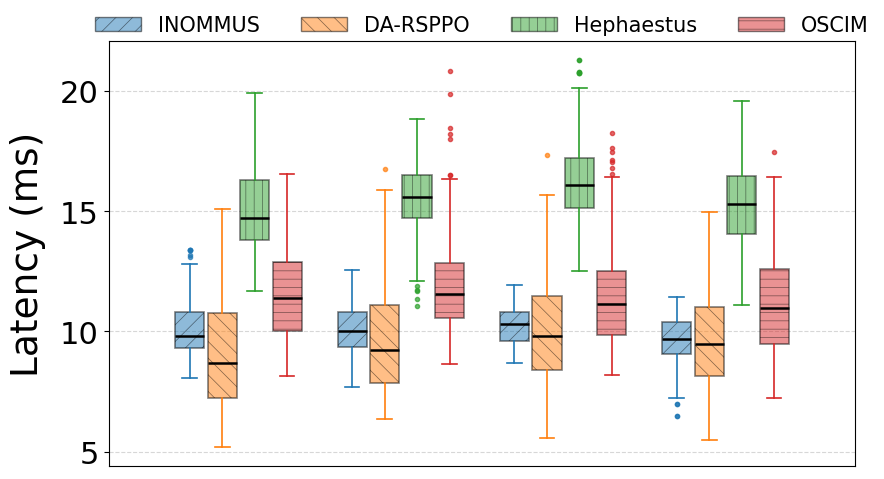

Gráfico exportado como PDF: boxplot_latency_Clean.pdf


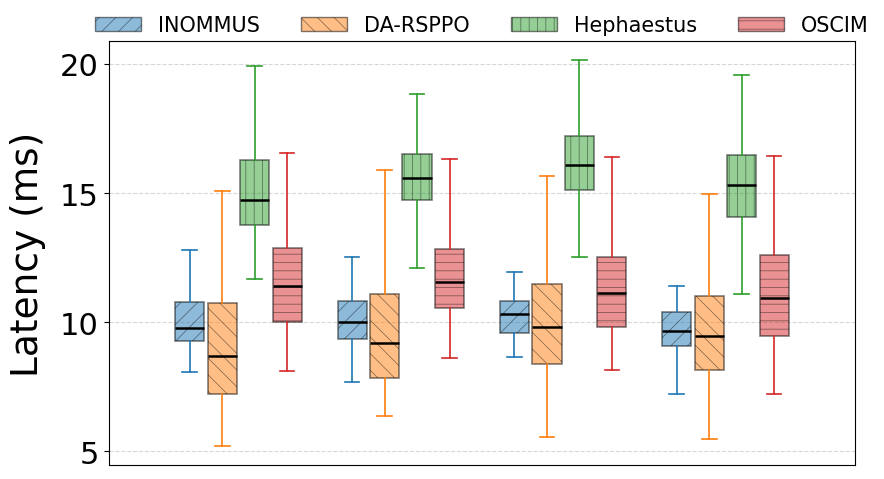

Gráfico exportado como PDF: boxplot_acceptance_rate_with_Outliers.pdf


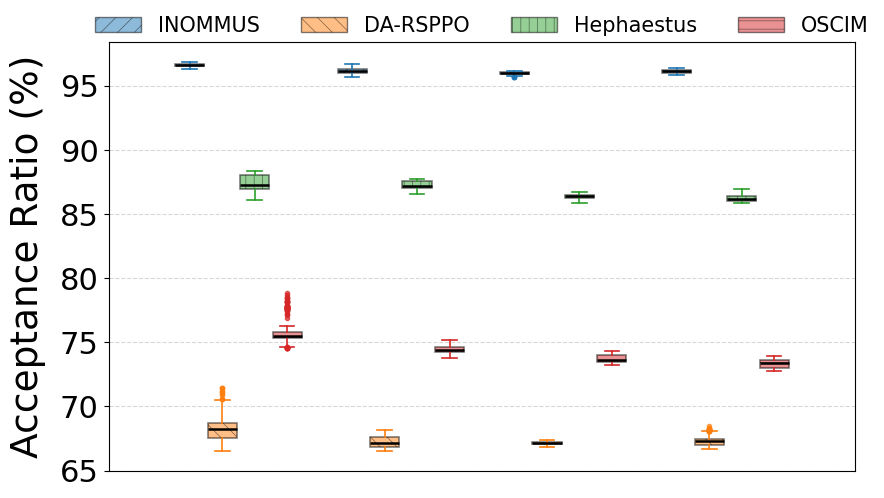

Gráfico exportado como PDF: boxplot_acceptance_rate_Clean.pdf


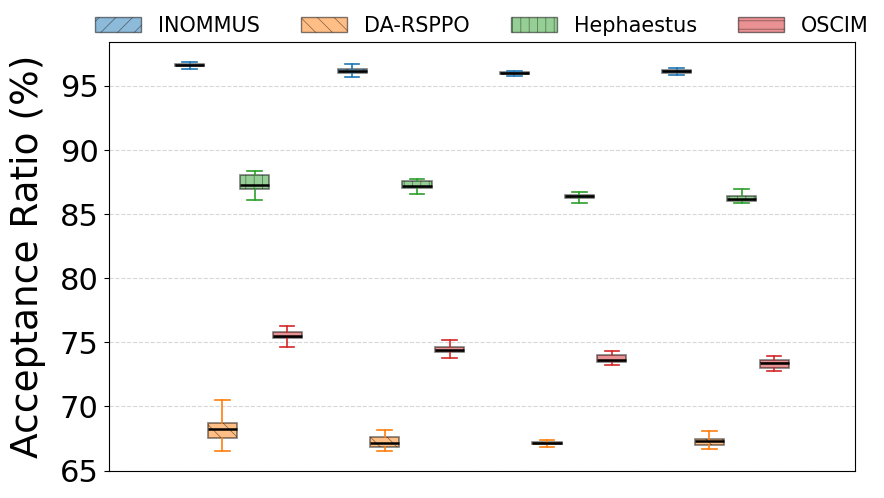

Gráfico exportado como PDF: boxplot_decision_time_ms_with_Outliers.pdf


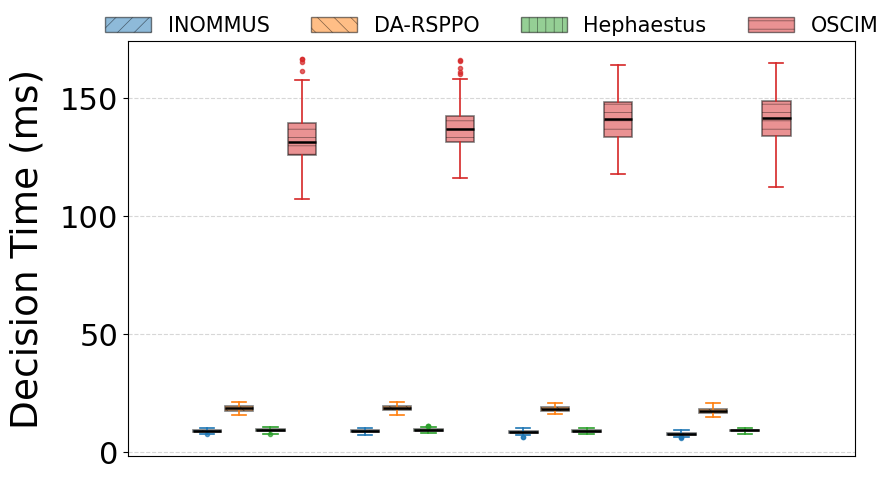

Gráfico exportado como PDF: boxplot_decision_time_ms_Clean.pdf


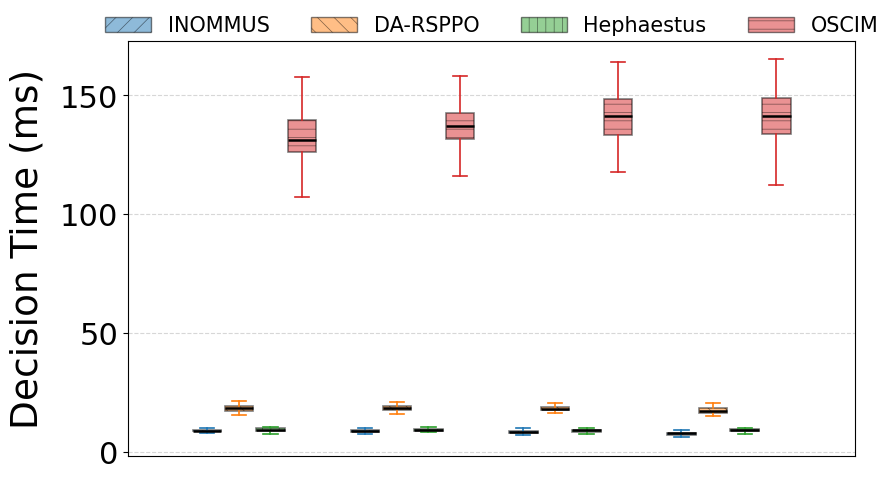

Gráfico exportado como PDF: boxplot_cpu_per_flow_with_Outliers.pdf


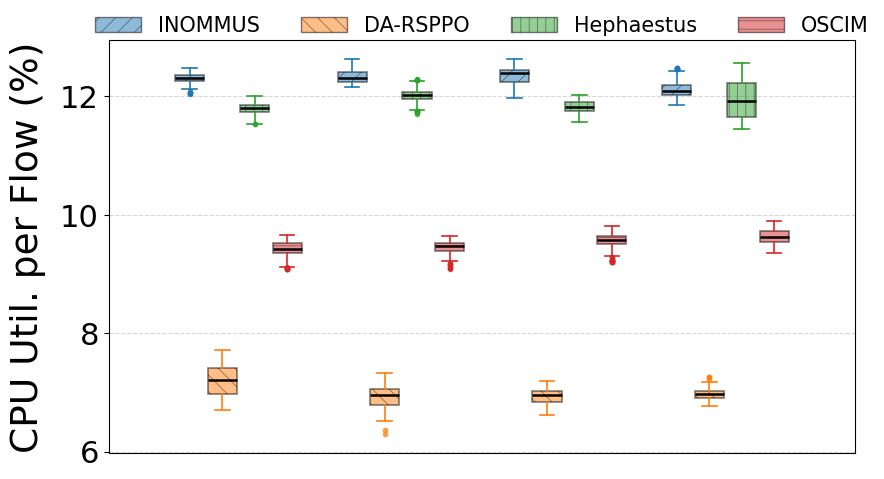

Gráfico exportado como PDF: boxplot_cpu_per_flow_Clean.pdf


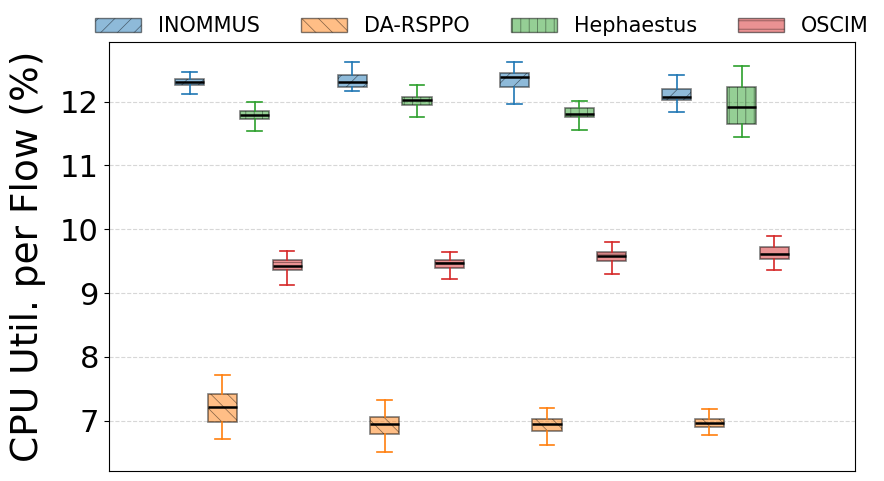

Gráfico exportado como PDF: boxplot_gpu_per_flow_with_Outliers.pdf


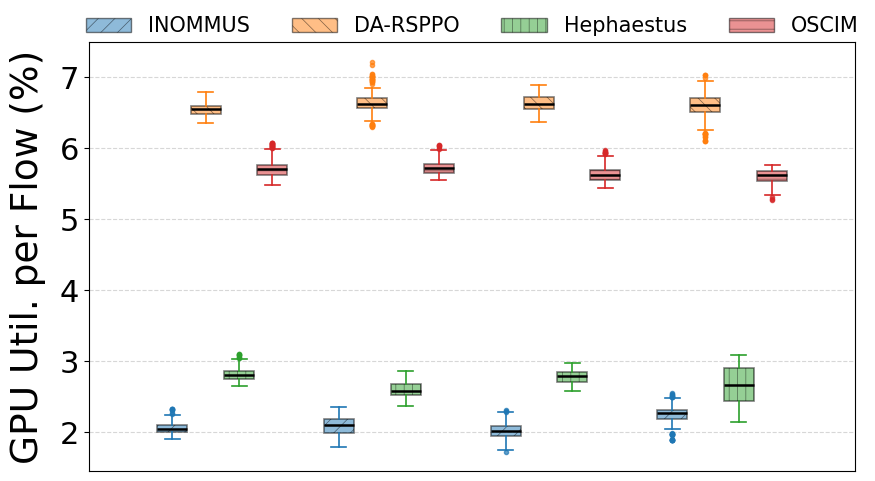

Gráfico exportado como PDF: boxplot_gpu_per_flow_Clean.pdf


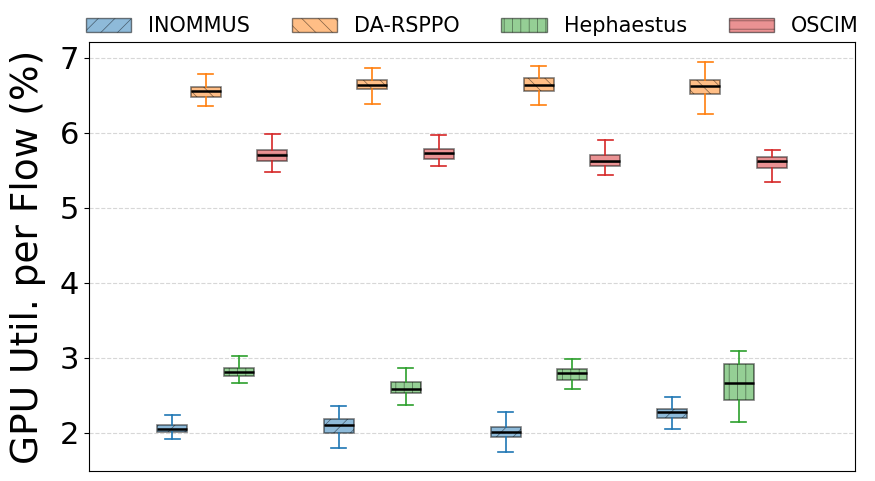

Gráfico exportado como PDF: boxplot_cache_per_flow_with_Outliers.pdf


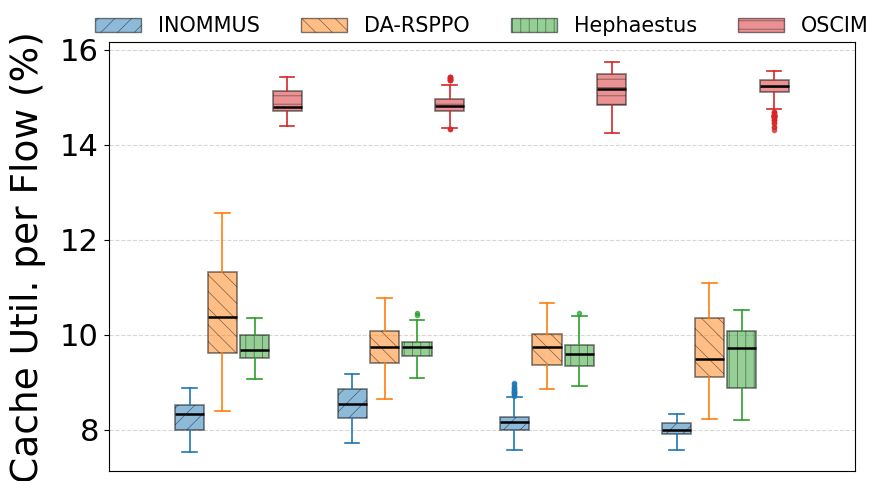

Gráfico exportado como PDF: boxplot_cache_per_flow_Clean.pdf


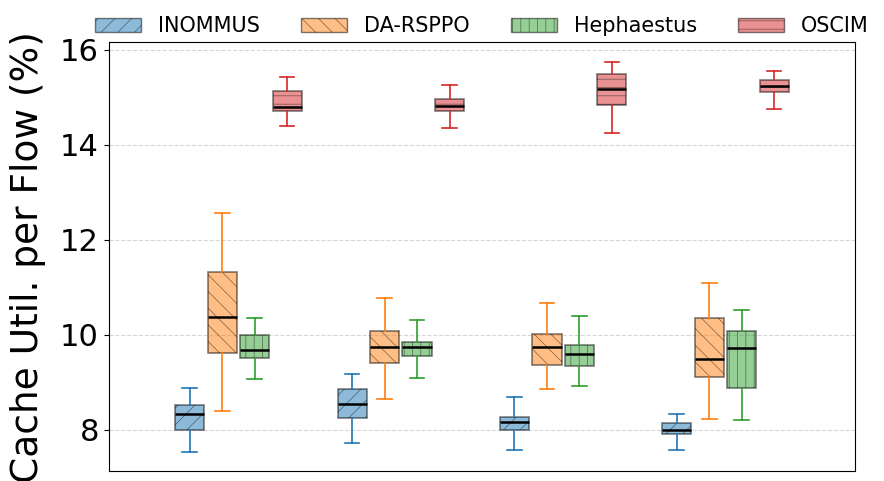

Gráfico exportado como PDF: boxplot_bandwidth_utilization_per_flow_with_Outliers.pdf


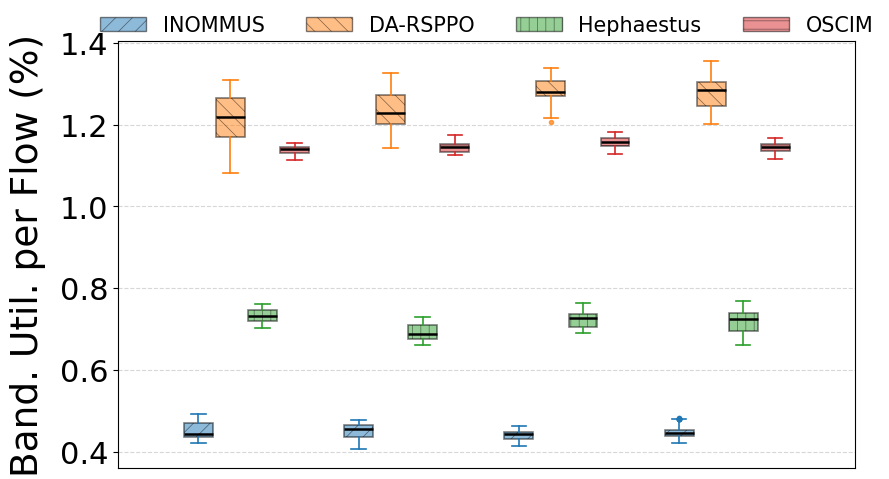

Gráfico exportado como PDF: boxplot_bandwidth_utilization_per_flow_Clean.pdf


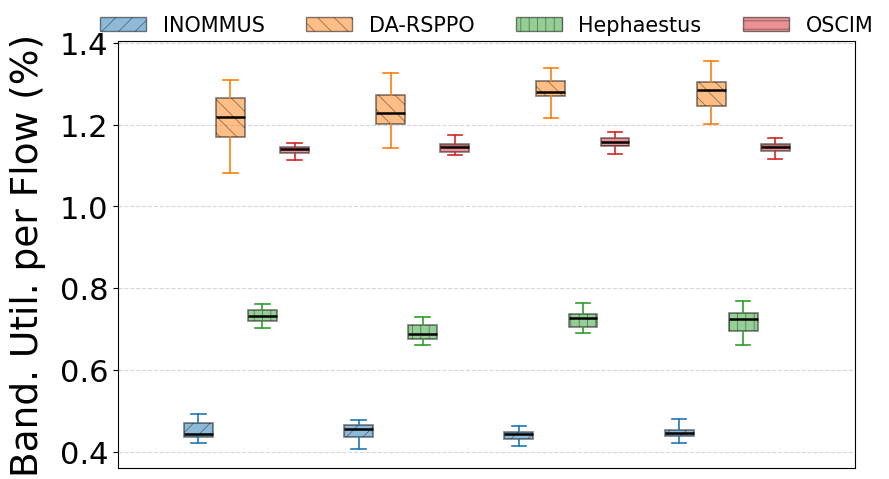

Gráfico exportado como PDF: boxplot_shared_vnfs_per_flow_with_Outliers.pdf


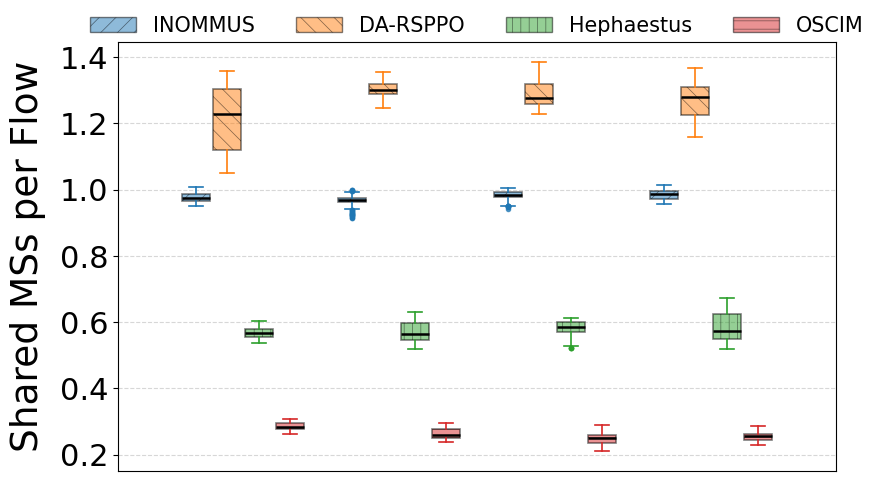

Gráfico exportado como PDF: boxplot_shared_vnfs_per_flow_Clean.pdf


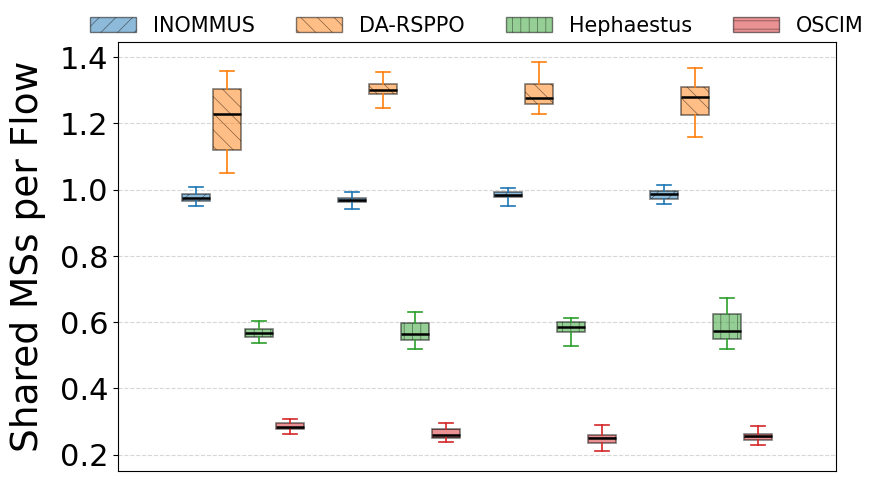

Gráfico exportado como PDF: boxplot_energy_consumption_per_flow_with_Outliers.pdf


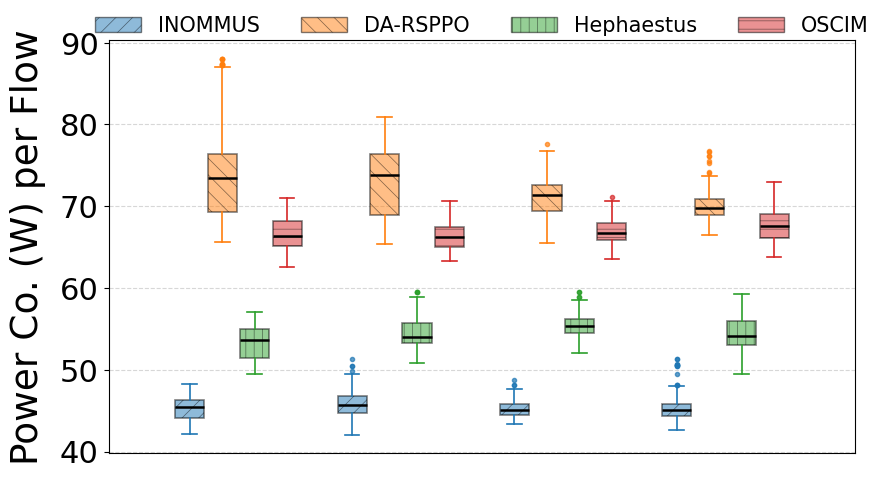

Gráfico exportado como PDF: boxplot_energy_consumption_per_flow_Clean.pdf


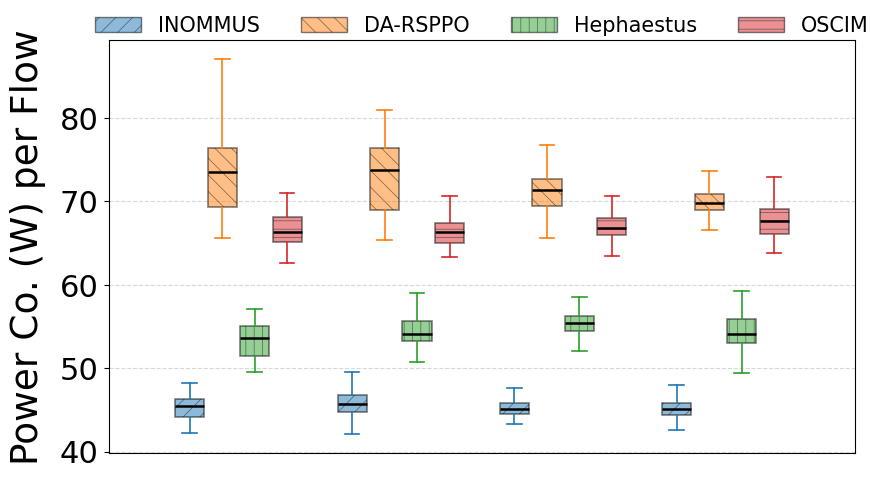

Gráfico exportado como PDF: boxplot_jain_fairness_latencia_por_sessao_with_Outliers.pdf


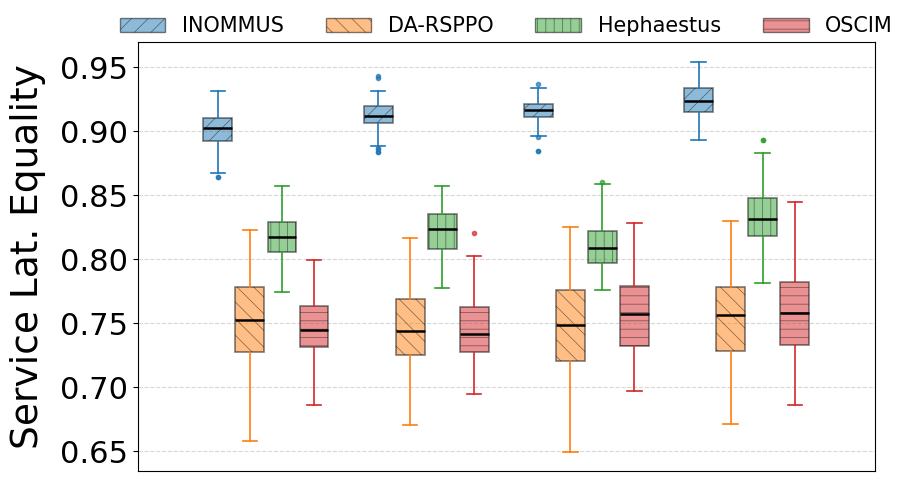

Gráfico exportado como PDF: boxplot_jain_fairness_latencia_por_sessao_Clean.pdf


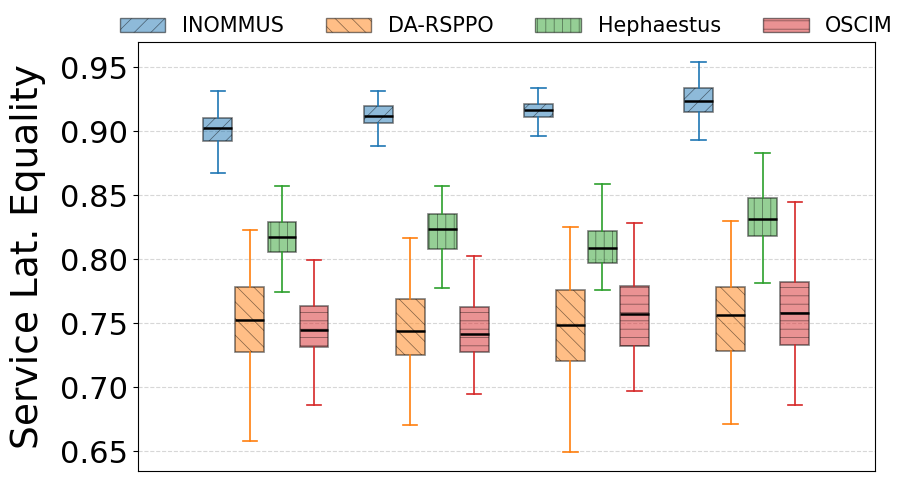

Gráfico exportado como PDF: boxplot_queue_time_with_Outliers.pdf


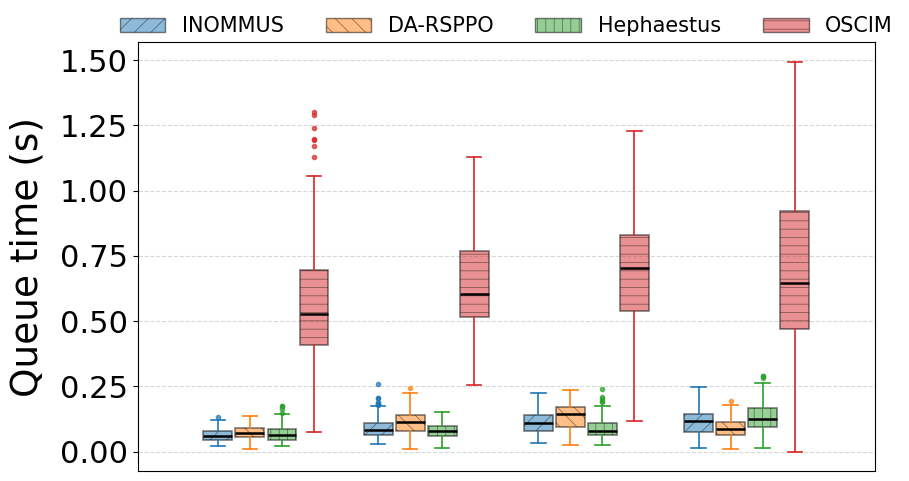

Gráfico exportado como PDF: boxplot_queue_time_Clean.pdf


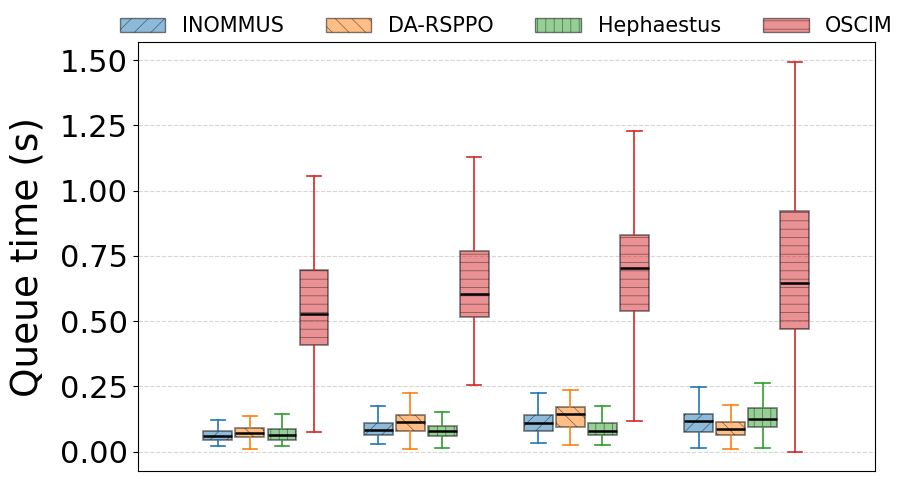

Gráfico exportado como PDF: boxplot_jain_cpu_with_Outliers.pdf


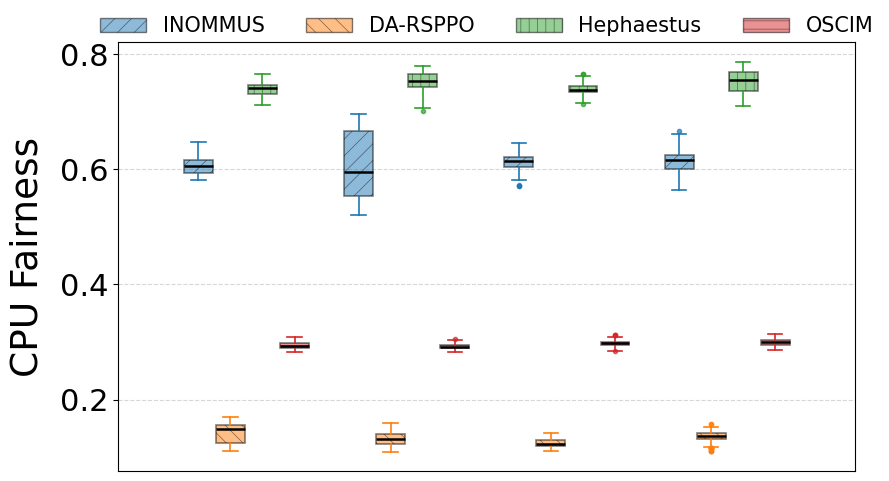

Gráfico exportado como PDF: boxplot_jain_cpu_Clean.pdf


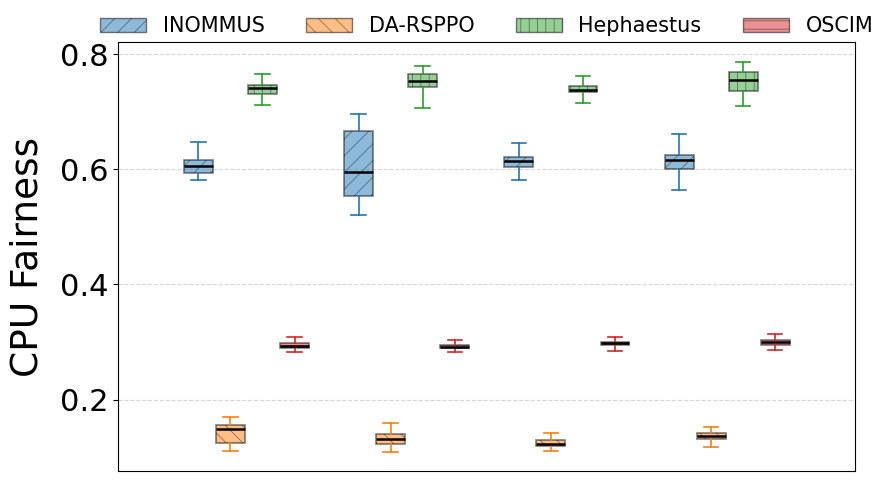

Gráfico exportado como PDF: boxplot_jain_gpu_with_Outliers.pdf


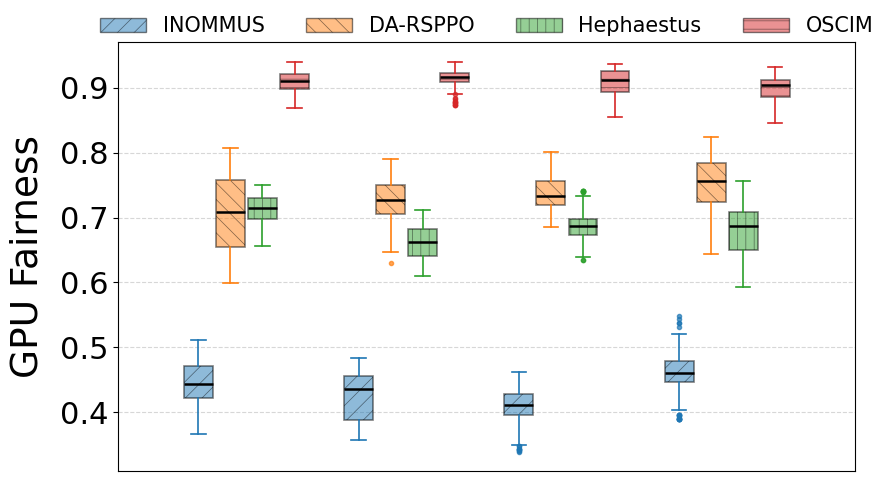

Gráfico exportado como PDF: boxplot_jain_gpu_Clean.pdf


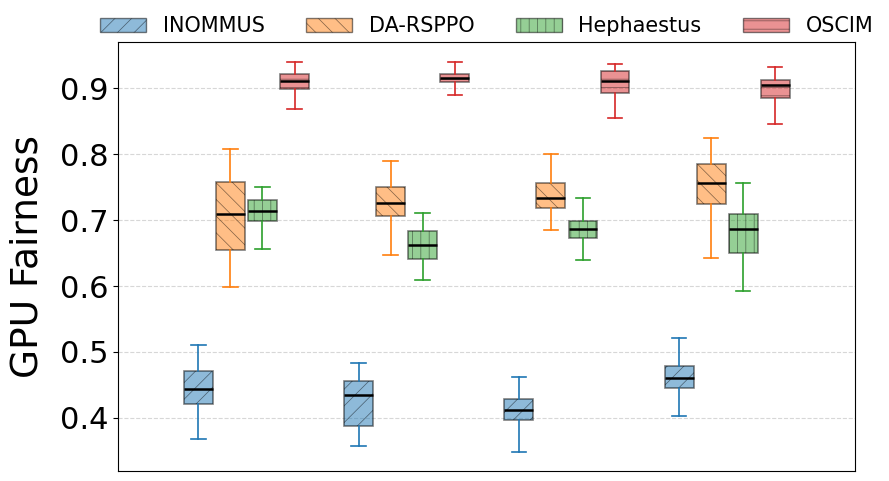

Gráfico exportado como PDF: boxplot_cache_per_flow_with_Outliers.pdf


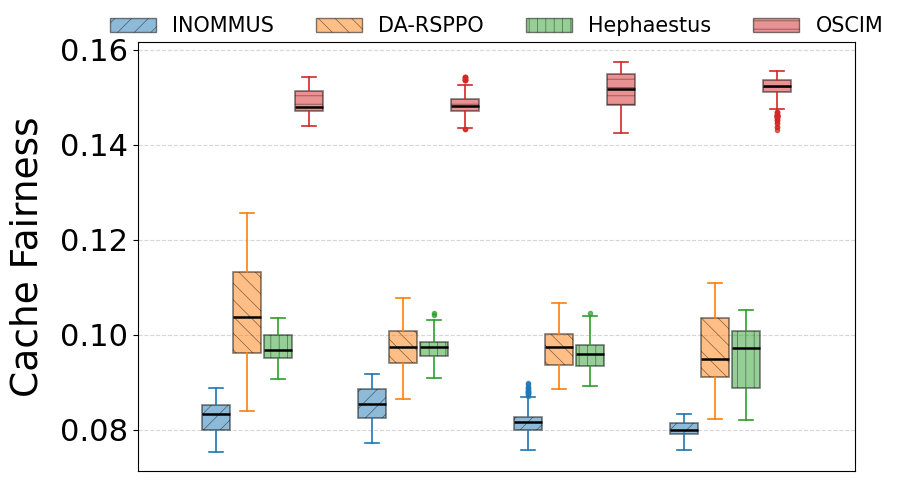

Gráfico exportado como PDF: boxplot_cache_per_flow_Clean.pdf


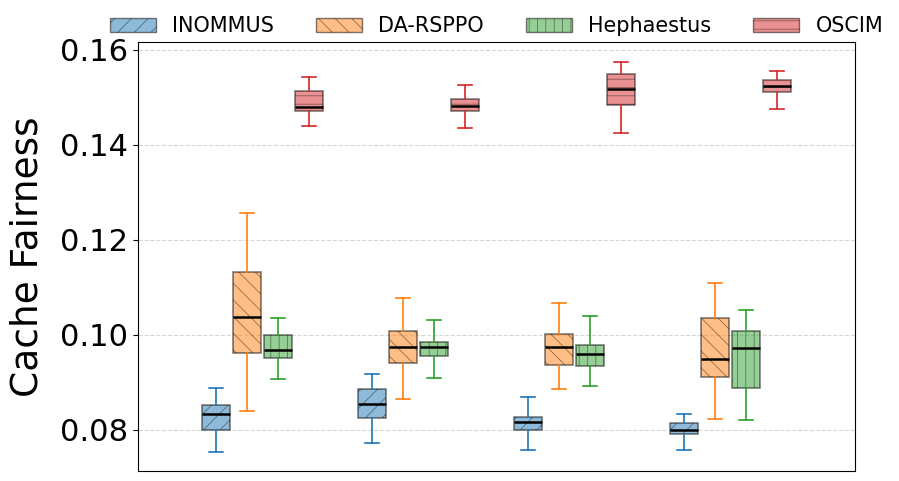

Gráfico exportado como PDF: boxplot_jain_bw_with_Outliers.pdf


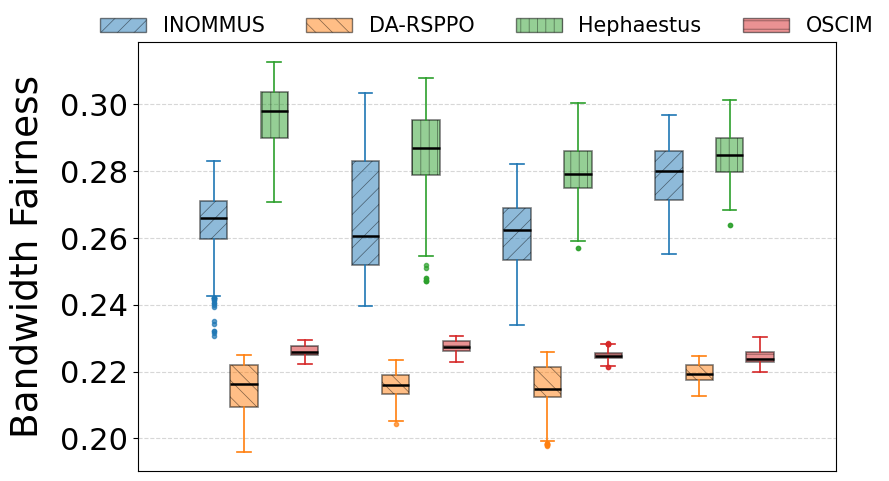

Gráfico exportado como PDF: boxplot_jain_bw_Clean.pdf


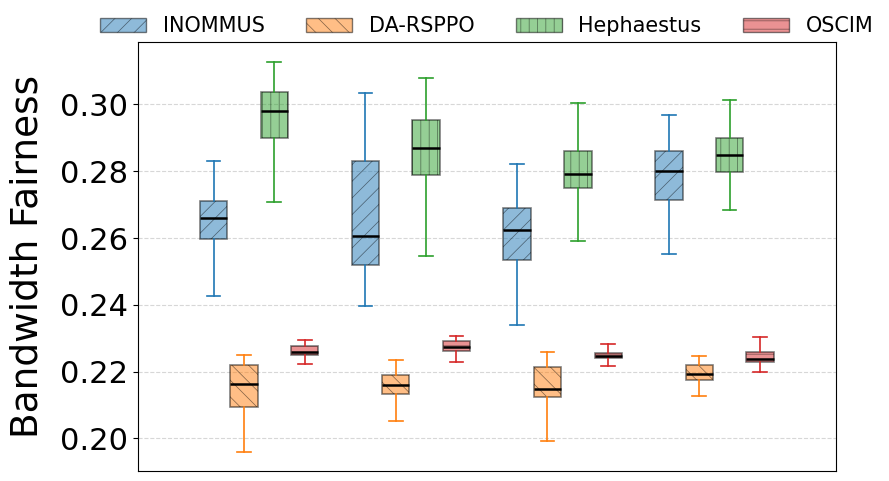

In [22]:
import re
import pandas as pd

# --- Métricas -> colunas (mantive os títulos que você já usa no eixo Y) ---
metricas = {
    #"CPU Utilization (%)": "cpu_utilization",
    #"GPU Utilization (%)": "gpu_utilization",
    #"Cache Utilization (%)": "cache_utilization",
    #"Bandwidth Utilization (%)": "bandwidth_utilization",
    "Latency (ms)": "latency",
    "Acceptance Ratio (%)": "acceptance_rate",
    "Decision Time (ms)": "decision_time_ms",
    #"N. of Shared MSs": "shared_vnfs",
    "CPU Util. per Flow (%)": "cpu_per_flow",
    "GPU Util. per Flow (%)": "gpu_per_flow",
    "Cache Util. per Flow (%)": "cache_per_flow",
    "Band. Util. per Flow (%)":"bandwidth_utilization_per_flow",
    "Shared MSs per Flow": "shared_vnfs_per_flow",
    #"Power Cons. (Ah)": "total_energy_consumption",
    "Power Co. (W) per Flow": "energy_consumption_per_flow",
    "Service Lat. Equality": "jain_fairness_latencia_por_sessao",
    "Queue time (s)": "queue_time",
    "CPU Fairness": "jain_cpu",
    "GPU Fairness": "jain_gpu",
    "Cache Fairness": "cache_per_flow",
    "Bandwidth Fairness": "jain_bw",
}

# --- Mapeamento de algoritmos para nomes de legenda ---
legendas = {
    'kuririnMaskablePPO': 'INOMMUS',
    'darsppoMaskablePPO': 'DA-RSPPO',
    'hephaestusMaskablePPO': 'Hephaestus',
    'GA': 'OSCIM',
}

# --- Parâmetros consistentes com os gráficos anteriores ---
WINDOW_STEPS = 200        # tamanho da janela de tempo (bins)
EXPORT_PDF = True         # exportar PDF
FIG_W, FIG_H = 900, 500   # px (~ 9.4 x 5.2 in)

# Itera por métrica e plota duas versões (com/sem outliers)
for titulo_grafico, coluna_df in metricas.items():
    # Multiplica por 100 se for métrica em %
    multiplicador = 100 if "%" in titulo_grafico else 1

    # Monta dict {nome_legenda: série}
    dados_para_plotar = {}
    for alg_id, legenda_nome in legendas.items():
        if alg_id not in dados_processados:
            print(f"[AVISO] Algoritmo '{alg_id}' não encontrado em 'dados_processados'. Pulando.")
            continue
        df_alg = dados_processados[alg_id]
        if coluna_df not in df_alg.columns:
            print(f"[AVISO] Coluna '{coluna_df}' ausente para '{alg_id}'. Pulando.")
            continue

        s = pd.to_numeric(df_alg[coluna_df], errors="coerce") * multiplicador
        dados_para_plotar[legenda_nome] = s

    if not dados_para_plotar:
        print(f"[AVISO] Sem dados válidos para '{titulo_grafico}'. Pulando.")
        continue

    # Gera versões com e sem outliers
    for show_outliers in (True, False):
        suffix = "_with_Outliers" if show_outliers else "_Clean"
        safe_col = re.sub(r"[^\w\-]+", "_", coluna_df.strip())
        pdf_path = f"boxplot_{safe_col}{suffix}.pdf" if EXPORT_PDF else None

        # Create the boxplot with adjusted changes
        create_boxplot(
            data_series_dict=dados_para_plotar,
            yaxis_title=titulo_grafico,
            xaxis_title="",  # Removed the x-axis title
            steps=WINDOW_STEPS,
            fill_missing=True,
            bfill_leading=True,
            show=True,                     # Display the plot
            pdf_filename=pdf_path,         # Save PDF (if EXPORT_PDF=True)
            width=FIG_W,
            height=FIG_H,
            show_outliers=show_outliers,   # Aligned with Matplotlib helper
        )


In [23]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Dict, Optional, Tuple, List

def create_binned_boxplot(
    df_full: pd.DataFrame,
    x_col: str,
    y_col: str,
    alg_col: str,
    legend_map: Dict[str, str],
    bin_size: int = 10,
    x_multiplier: float = 100.0,
    yaxis_title: str = 'Y Axis',
    xaxis_title: str = 'X Axis',  # Add default xaxis_title
    show: bool = True,
    pdf_filename: Optional[str] = None,  # Ensure this defaults to None for manual handling
    width: int = 950,
    height: int = 600,
    show_outliers: bool = True,
) -> Tuple[Optional[plt.Figure], pd.DataFrame]:
    """
    Creates grouped boxplots (Matplotlib) of y_col vs. binned x_col for each algorithm.
    Bins x_col values, groups by algorithm, and plots side-by-side boxes per bin.
    """

    # --- Prepare data ---
    df_plot = df_full.copy()
    df_plot = df_plot[df_plot[alg_col].isin(legend_map.keys())]

    if df_plot.empty:
        print("[ERRO] Nenhum dado encontrado para os algoritmos em 'legend_map'.")
        return None, pd.DataFrame()

    # Map algorithm names
    df_plot['Algorithm'] = df_plot[alg_col].map(legend_map)

    # Scale and bin x values
    df_plot[f"{x_col}_scaled"] = df_plot[x_col] * x_multiplier
    df_plot[f"{x_col}_bin"] = (np.ceil(df_plot[f"{x_col}_scaled"] / bin_size)) * bin_size
    df_plot[f"{x_col}_bin"] = df_plot[f"{x_col}_bin"].astype(int)

    # Sort bins
    x_bins = sorted(df_plot[f"{x_col}_bin"].unique())

    # --- Plot styling ---
    plt.rcParams['hatch.linewidth'] = 0.5
    plt.rcParams.update({
        'font.size': 22,
        'axes.labelsize': 22,
        'legend.fontsize': 13,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'axes.titlesize': 20,
    })

    dpi_guess = 96
    fig_w = max(6, width / dpi_guess)
    fig_h = max(4, height / dpi_guess)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    alg_order = list(df_plot['Algorithm'].unique())
    n_alg = len(alg_order)
    group_width = 0.8
    box_width = group_width / n_alg
    positions_base = np.arange(len(x_bins))

    CORES_ALGORITMOS = {
    "INOMMUS": "#1f77b4",
    "DA-RSPPO": "#ff7f0e",
    "Hephaestus": "#2ca02c",
    "OSCIM": "#d62728",
    # adicione mais se houver
    }

    # Colors & hatches
    def _color_for(i: int, name: str) -> any:
        try:
            return cores_algoritmos.get(name, plt.cm.tab10(i % 10))  # type: ignore
        except Exception:
            return plt.cm.tab10(i % 10)

    hatch_patterns = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']
    legend_handles: List[Patch] = []

    # --- Draw grouped boxplots ---
    for i, alg in enumerate(alg_order):
        color = CORES_ALGORITMOS.get(alg, plt.cm.tab10(i % 10))
        hatch = hatch_patterns[i % len(hatch_patterns)]

        df_alg = df_plot[df_plot['Algorithm'] == alg]
        data_per_bin = [
            df_alg[df_alg[f"{x_col}_bin"] == xb][y_col].dropna().values
            for xb in x_bins
        ]

        offset = (i - n_alg / 2) * box_width + box_width / 2
        positions = positions_base + offset

        flier_style = dict(
            marker='o',
            markersize=3,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.7
        )

        bp = ax.boxplot(
            data_per_bin,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            showfliers=show_outliers,
            boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5,
                          linewidth=1.2, edgecolor='black'),
            medianprops=dict(color='black', linewidth=1.8),
            whiskerprops=dict(color=color, linewidth=1.2),
            capprops=dict(color=color, linewidth=1.2),
            flierprops=flier_style if show_outliers else dict(marker='o', markersize=0.1)
        )

        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.2)
            patch.set_alpha(0.5)
            patch.set_hatch(hatch)

        legend_handles.append(Patch(
            facecolor=color, edgecolor='black', hatch=hatch, alpha=0.5, label=alg
        ))

    # --- Axes formatting ---
    ax.set_ylabel(yaxis_title, labelpad=10)
    ax.set_xlabel(xaxis_title, labelpad=10)  # Restore x-axis title
    ax.set_xticks(positions_base)
    ax.set_xticklabels([str(x) for x in x_bins])  # Show x-axis labels
    ax.tick_params(axis='x', which='both', bottom=True, top=False)  # Show ticks
    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)

    # Legend above the plot
    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=min(4, n_alg),
        frameon=True,
        handlelength=2.2,
        borderpad=0.3,
        labelspacing=0.4
    )

    plt.tight_layout(pad=0.9)

    # --- Export ---
    if pdf_filename:
        try:
            # Overwrite the existing PDF if it exists
            fig.savefig(pdf_filename, dpi=300, bbox_inches='tight', overwrite=True)
            print(f"Gráfico exportado como PDF: {pdf_filename}")
        except Exception as e:
            base, _ = os.path.splitext(pdf_filename)
            png_out = f"{base}.png"
            print(f"Falha ao exportar PDF ({e.__class__.__name__}). Salvando PNG.")
            fig.savefig(png_out, dpi=300, bbox_inches='tight')
            print(f"Gráfico exportado como PNG: {png_out}")

    fig.savefig('a.pdf', dpi=300, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, df_plot


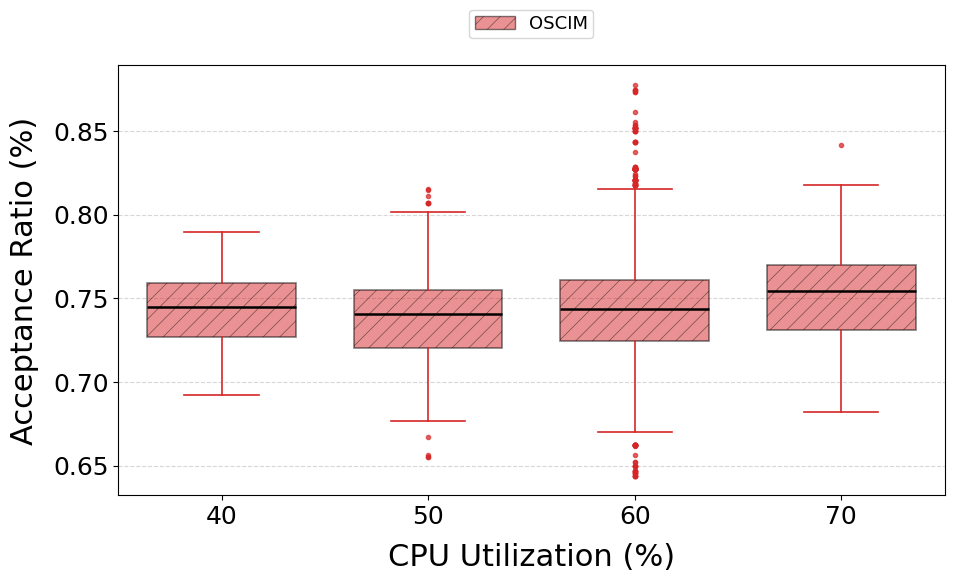

(<Figure size 989.583x625 with 1 Axes>,
        tempo  cpu_utilization  gpu_utilization  cache_utilization  \
 9933     200           0.2680           0.7191             0.5488   
 9934     201           0.2680           0.7191             0.5488   
 9935     202           0.2680           0.7191             0.5488   
 9936     203           0.2652           0.7342             0.5488   
 9937     204           0.2652           0.7342             0.5488   
 ...      ...              ...              ...                ...   
 19477    995           0.3342           0.7156             0.5488   
 19478    996           0.3342           0.7156             0.5488   
 19479    997           0.3342           0.7156             0.5488   
 19480    998           0.3342           0.7156             0.5488   
 19481    999           0.3342           0.7156             0.5488   
 
        network_cpu_utilization  network_gpu_utilization  \
 9933                   44.3475                  71.9106  

In [24]:

#legendas_map = {
#    'Kuririn PPO': 'INOMMUS',
#    'DARSPPO': 'DA-RSPPO',
#    'hephaestus': 'Hephaestus',
#    'GA': 'OSCIM',
#}

legendas_map = {
    'GA': 'OSCIM',
    'DARSPPO': 'DA-RSPPO',
    'hephaestus': 'Hephaestus',
    'Kuririn PPO': 'INOMMUS'
}

# x_col='bandwidth_utilization', 'cpu_utilization', 'cache_utilization'
create_binned_boxplot(
    df_full=big_data,
    x_col='bandwidth_utilization',
    y_col='acceptance_rate',
    alg_col='algorithm',
    legend_map=legendas_map,
    bin_size=10,
    x_multiplier=100.0,
    yaxis_title='Acceptance Ratio (%)',
    xaxis_title='CPU Utilization (%)'
)
